In [1]:
import os
import math
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
data_path = "../raw_data"
cancer_type = "brca"

In [3]:
data = [f"{data_path}/data_mrna_seq_v2_rsem_zscores_ref_all_samples.txt",
        f"{data_path}/{cancer_type}_tcga_clinical_data.tsv"]

## Gene Expression Data

In [4]:
def load_expression_data(data_path, drop_nan_columns=True, drop_na=True, handle_missingness=True, handle_duplicate_cols=True):
    
    # Dropping "Entrez_Gene_Id at the time of loading the data
    df_exp = pd.read_csv(data_path, sep = '\t').drop('Entrez_Gene_Id', axis = 1)
    
    # Setting Hugo_Symbol as the Index
    df_exp = df_exp.set_index('Hugo_Symbol').T    
    
    if drop_nan_columns:
        print(f"*"*50)
        print(f"Begin cleaning columns name is NaN")
        print(f"df_exp.shape: {df_exp.shape}")
        
        # check if column name contains nan
        has_nan = pd.isna(df_exp.columns).any()
        print(f"Are there nans' in column names: {has_nan}")
        
        df_exp = df_exp.loc[:, df_exp.columns.notna()]
        print(f"df_exp.shape: {df_exp.shape}")
        print(f"End cleaning columns name is NaN")
        print(f"*"*50)
    
    if drop_na:
        print(f"Begin dropping columns if all values are NaN")
        # Are there any columns with all 0s
        count_nans = df_exp.isna().sum()
        print(f"Number of GENEs where all values are NaNs: {count_nans[count_nans==df_exp.shape[0]].shape[0]}")
        nan_columns = list(count_nans[count_nans==df_exp.shape[0]].index)
    
        #Dropping a column if it contains all NaN values
        df_exp = df_exp.dropna(axis=1, how='all')
        print(f"df_exp.shape: {df_exp.shape}")
        print(f"End dropping columns if all values are NaN")
        print(f"*"*50)
    
    if handle_missingness:
        print(f"Begin handling missing values logic")
        count_nans = df_exp.isna().sum()        
        # Are there any missing values
        print(f"Number of GENEs with missingness > 0: {count_nans[count_nans>0].shape[0]}")
        missingness_columns = list(count_nans[count_nans>0].index)
        print(f"End handling missing values logic")
        print(f"*"*50)
        
    if handle_duplicate_cols:
        print(f"Begin handling duplicate columns")
        df_exp_avg = df_exp.copy()#[df_exp.columns]
        col_counts = pd.Series(df_exp.columns).value_counts()
        duplicate_columns = col_counts[col_counts > 1].index.tolist()
        print(f"df_exp.shape: {df_exp.shape}")
        print(f"df_exp_avg.shape: {df_exp_avg.shape}")
        print(f"number of duplicate_columns: {len(duplicate_columns)}")
        print(f"df_exp[duplicate_columns].shape: {df_exp[duplicate_columns].shape}") 
        
        df_exp_avg = df_exp_avg.groupby(by=df_exp_avg.columns, axis=1).mean()
        print(f"Assertion: df_exp.shape[1]({df_exp.shape[1]}) - len(duplicate_columns)({len(duplicate_columns)}) = df_exp_avg.shape[1]({df_exp_avg.shape[1]})")
        
        print(f"End handling duplicate columns")
        print(f"*"*50)
        
        
    # Renaming the index as SAMPLE_ID and resetting_the index
    df_exp = df_exp_avg.rename_axis('SAMPLE_ID').reset_index()
    
    return df_exp, nan_columns, missingness_columns, duplicate_columns

In [5]:
# df_exp = pd.read_csv(data_path, sep = '\t').drop('Entrez_Gene_Id', axis = 1)

In [6]:
df_exp, nan_columns_exp, missingness_columns_exp, duplicate_columns_exp = load_expression_data(data[0])
df_exp.head()

**************************************************
Begin cleaning columns name is NaN
df_exp.shape: (1100, 20531)
Are there nans' in column names: True
df_exp.shape: (1100, 20530)
End cleaning columns name is NaN
**************************************************
Begin dropping columns if all values are NaN
Number of GENEs where all values are NaNs: 319
df_exp.shape: (1100, 20211)
End dropping columns if all values are NaN
**************************************************
Begin handling missing values logic
Number of GENEs with missingness > 0: 0
End handling missing values logic
**************************************************
Begin handling duplicate columns
df_exp.shape: (1100, 20211)
df_exp_avg.shape: (1100, 20211)
number of duplicate_columns: 17
df_exp[duplicate_columns].shape: (1100, 34)
Assertion: df_exp.shape[1](20211) - len(duplicate_columns)(17) = df_exp_avg.shape[1](20194)
End handling duplicate columns
**************************************************


Hugo_Symbol,SAMPLE_ID,133K02,5T4,A-C1,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,...,ZWILCH,ZWINT,ZWS1,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZZ3
0,TCGA-3C-AAAU-01,0.0821,-2.1210,0.3060,0.4191,0.1657,-1.1186,-0.9584,0.4633,-0.7625,...,-0.1043,0.4389,0.9410,1.6674,1.3652,1.7323,1.1787,1.0112,0.0077,0.7011
1,TCGA-3C-AALI-01,-1.1634,-1.1767,0.7383,0.6462,1.5168,-1.1186,-0.5741,0.3347,-0.4075,...,2.2599,0.4917,0.8740,0.0469,-0.2845,0.8841,0.9389,-0.8990,0.9335,-1.8110
2,TCGA-3C-AALJ-01,-1.0405,-0.0972,-0.2167,1.3532,0.7521,0.4587,-0.3511,-0.6383,-1.1419,...,-0.8136,1.9444,-0.6236,-1.0439,0.0704,-1.3588,1.4057,-1.2453,0.9163,-1.2802
3,TCGA-3C-AALK-01,-0.5932,1.7668,-0.2767,0.3809,0.0495,-1.1186,-0.0415,-0.5797,-0.7144,...,-0.2253,-0.0611,-0.8910,-0.1270,-0.3346,-0.8902,0.8269,-0.8818,1.0020,-0.5286
4,TCGA-4H-AAAK-01,-0.1301,0.9166,0.1489,0.7984,0.8357,-0.2521,-0.2346,0.4275,-0.4927,...,-0.1609,-0.0480,0.1776,-0.3710,-0.3982,-0.1067,-1.4182,-0.2086,0.2990,0.0127


## Clinical Data

In [16]:
def load_clinical_data(data_path):
    
    #load the clinical data
    df_clinical = pd.read_csv(data_path, sep = '\t')
    
    # Selecting only the important columns
    df_clinical = df_clinical[['Patient ID', 'Sample ID', 'Cancer Type', 'Sample type id', 'Vial number', 'Overall Survival (Months)', 'Overall Survival Status']]
    
    # Renaming a couple of columns
    df_clinical = df_clinical.rename(columns = {'Patient ID' : 'PATIENT_ID', 
                                                'Sample ID' : 'SAMPLE_ID', 
                                                'Cancer Type' : 'CANCER_TYPE',
                                                'Sample type id' : 'SAMPLE_TYPE_ID',
                                                'Vial number' : 'VIAL_NUMBER',
                                                'Overall Survival (Months)' : 'OS_MONTHS', 
                                                'Overall Survival Status' : 'OS_STATUS'})
    
    # Ensure to select only Glioma cases
    mask1 = df_clinical['CANCER_TYPE']=='Breast Cancer'
    
    # Ensure to select sample type 1 only.
    mask2 = df_clinical['SAMPLE_TYPE_ID']==1
    
    # Ensure to avoid selecting vial number 'B' samples.
    mask3 = df_clinical['VIAL_NUMBER']!='B'
    
    # remove NaNs in the raw data
    mask4 = df_clinical['OS_STATUS'].notnull()
    
    # Remove samples with Negative OS_MONTHS
    # df_clinical['OS_STATUS
    mask5 = df_clinical['OS_MONTHS']>=0
    
    print(f'Before mask conditions, df_clinical.shape: {df_clinical.shape}')
    
    df_clinical = df_clinical[(mask1) & (mask2) & (mask3) & (mask4) & (mask5)]
    
    print(f'After mask conditions, df_clinical.shape: {df_clinical.shape}')
    
    # Selecting only the important columns
    #df_clinical = df_clinical[['Patient ID', 'Sample ID', 'Overall Survival Status', 'Overall Survival (Months)']]
    
    # Renaming a couple of columns
    #df_clinical = df_clinical.rename(columns = {'Patient ID': 'Patient_ID', 'Sample ID': 'SAMPLE_ID', 'Overall Survival Status':'OS_STATUS', 'Overall Survival (Months)':'OS_MONTHS'})
    
    print(f'df_clinical["OS_STATUS"].value_counts(dropna=False): {df_clinical["OS_STATUS"].value_counts(dropna=False)}') 
    
    # Updating OS_STATUS
    df_clinical['OS_STATUS'] = df_clinical['OS_STATUS'].apply(lambda x : 0 if str(x).find('LIVING') != -1 else 1)
    
    # Dropping OS_MONTHS data with Nan values
    df_clinical = df_clinical[~df_clinical['OS_MONTHS'].isna()]
    
    df_clinical = df_clinical.reset_index(drop = True)
    
    df_clinical.OS_MONTHS = df_clinical.OS_MONTHS.astype('float64')
    
    return df_clinical

In [17]:
df_clinical = load_clinical_data(data[1])

Before mask conditions, df_clinical.shape: (1108, 7)
After mask conditions, df_clinical.shape: (1081, 7)
df_clinical["OS_STATUS"].value_counts(dropna=False): OS_STATUS
0:LIVING      931
1:DECEASED    150
Name: count, dtype: int64


In [18]:
# df_clinical = pd.read_csv(data[1], sep = '\t')
# df_clinical = df_clinical[['Patient ID', 'Sample ID', 'Cancer Type', 'Sample type id', 'Vial number', 'Overall Survival (Months)']]

In [21]:
df_clinical.head()

,PATIENT_ID,SAMPLE_ID,CANCER_TYPE,SAMPLE_TYPE_ID,VIAL_NUMBER,OS_MONTHS,OS_STATUS
0,TCGA-3C-AALI,TCGA-3C-AALI-01,Breast Cancer,1,A,131.57,0
1,TCGA-3C-AALJ,TCGA-3C-AALJ-01,Breast Cancer,1,A,48.42,0
2,TCGA-3C-AALK,TCGA-3C-AALK-01,Breast Cancer,1,A,47.57,0
3,TCGA-4H-AAAK,TCGA-4H-AAAK-01,Breast Cancer,1,A,11.43,0
4,TCGA-5L-AAT0,TCGA-5L-AAT0-01,Breast Cancer,1,A,48.52,0


In [24]:
# df_clinical['Cancer Type'].value_counts()

In [25]:
df_clinical['PATIENT_ID'].nunique(), df_clinical['SAMPLE_ID'].nunique(), df_clinical['CANCER_TYPE'].nunique(), df_clinical['SAMPLE_TYPE_ID'].nunique(), df_clinical['VIAL_NUMBER'].nunique(), df_clinical['OS_STATUS'].nunique()

(1081, 1081, 1, 1, 1, 2)

In [26]:
df_clinical['OS_STATUS'].value_counts(dropna=True)

OS_STATUS
0    931
1    150
Name: count, dtype: int64

---

# Pathway

---

In [27]:
pathways_data = pd.read_csv(f"../metadata/pathway_db2.csv")

pathways_data.head()

,0,1,2,3,4,5,6,7,8,9,...,438,439,440,441,442,443,444,445,446,447
0,KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS,ALDOB,ENO3,LDHB,PGAM4,ALDH3B2,ADH5,AKR1A1,LDHAL6B,MINPP1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KEGG_CITRATE_CYCLE_(TCA_CYCLE),SUCLA2,IDH1,SDHA,ACO2,OGDH,SUCLG1,ACLY,OGDHL,PDHA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KEGG_PENTOSE_PHOSPHATE_PATHWAY,ALDOB,PRPS1L1,PGD,H6PD,PGLS,PRPS1,GLYCTK,SHPK,RBKS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS,UGT1A6,DHDH,UGT2A1,AKR1A1,UGT1A1,SORD,DCXR,UGT1A3,UGT2B28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,MPI,ALDOB,PFKFB2,PMM2,GMPPA,SORD,PFKP,PFKFB4,FBP2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
pathway_sizes = pathways_data.count(axis=1) - 1

In [29]:
pathway_sizes

0       67
1       30
2       31
3       36
4       34
      ... 
252     90
253     62
254     34
255     97
256    233
Length: 257, dtype: int64

In [30]:
pathways_data.shape

(257, 448)

In [31]:
pathways_data.shape

(257, 448)

In [32]:
### Discussed with Dr. Kang on March 12, 2019
# exclude large (i.e. > 300) AND small (i.e. < 15) pathways 
'''Exclude small and large sizes of pathways'''
def pathway_filter(pathways_data, small_cutoff, large_cutoff):
    # minus first column (i.e. pathway_name)
    pathway_sizes = pathways_data.count(axis=1) - 1
    pathways = pathways_data[(pathway_sizes > small_cutoff) & (pathway_sizes < large_cutoff)]
    return(pathways)

pathways = pathway_filter(pathways_data, 15, 300)
print("Number of pathways with length between 15 and 300: ", pathways.shape[0])

# Reset Indices
pathways = pathways.reset_index(drop=True)

# Dropping Columns with All NaN values after filtering pathways
pathways = pathways.dropna(axis=1, how='all')

# Correcting column names
pathways.columns = range(pathways.shape[1])

# Renaming 0th column as Pathway
pathways = pathways.rename(columns={0:'Pathway'})

# .head() of final pathways
pathways.head()

Number of pathways with length between 15 and 300:  231


,Pathway,1,2,3,4,5,6,7,8,9,...,289,290,291,292,293,294,295,296,297,298
0,KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS,ALDOB,ENO3,LDHB,PGAM4,ALDH3B2,ADH5,AKR1A1,LDHAL6B,MINPP1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KEGG_CITRATE_CYCLE_(TCA_CYCLE),SUCLA2,IDH1,SDHA,ACO2,OGDH,SUCLG1,ACLY,OGDHL,PDHA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KEGG_PENTOSE_PHOSPHATE_PATHWAY,ALDOB,PRPS1L1,PGD,H6PD,PGLS,PRPS1,GLYCTK,SHPK,RBKS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS,UGT1A6,DHDH,UGT2A1,AKR1A1,UGT1A1,SORD,DCXR,UGT1A3,UGT2B28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,MPI,ALDOB,PFKFB2,PMM2,GMPPA,SORD,PFKP,PFKFB4,FBP2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
pathway_name = pathways['Pathway']
pathway_name

0                      KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS
1                         KEGG_CITRATE_CYCLE_(TCA_CYCLE)
2                         KEGG_PENTOSE_PHOSPHATE_PATHWAY
3          KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS
4                   KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM
                             ...                        
226                    KEGG_LONGEVITY_REGULATING_PATHWAY
227    KEGG_LONGEVITY_REGULATING_PATHWAY_-_MULTIPLE_S...
228                                KEGG_CIRCADIAN_RHYTHM
229                           KEGG_CIRCADIAN_ENTRAINMENT
230                                   KEGG_THERMOGENESIS
Name: Pathway, Length: 231, dtype: object

In [34]:
set_pathway = {'pathway':[], 'gene':[]}
def make_pathway_set(pathway_df):
    set_pathway['pathway'].append(pathway_df[~pathway_df.isna()].Pathway)
    set_pathway['gene'].append(pathway_df[~pathway_df.isna()][1:])

pathways.apply(make_pathway_set, 1)

0      None
1      None
2      None
3      None
4      None
       ... 
226    None
227    None
228    None
229    None
230    None
Length: 231, dtype: object

In [35]:
pathway_list = np.concatenate(pathways.iloc[:, 1:].values.astype('str'), axis=None)
pathway_list

array(['ALDOB', 'ENO3', 'LDHB', ..., 'nan', 'nan', 'nan'], dtype='<U15')

In [36]:
pathway_list.size

68838

In [37]:
np.unique(pathway_list), np.unique(pathway_list).size 

(array(['A2M', 'A3GALT2', 'A4GALT', ..., 'ZNRF3', 'ZYX', 'nan'],
       dtype='<U15'),
 7224)

In [38]:
# set(duplicate_columns_exp).intersection(set(pathway_list))

In [39]:
unique_gene_in_pathway = np.delete(np.unique(pathway_list), np.where(np.unique(pathway_list)=='nan'))
unique_gene_in_pathway

array(['A2M', 'A3GALT2', 'A4GALT', ..., 'ZNHIT1', 'ZNRF3', 'ZYX'],
      dtype='<U15')

In [40]:
unique_gene_in_pathway.size ### number of genes in KEGG

7223

---

## Concat mRNA and labels

In [41]:
df_exp.head()

Hugo_Symbol,SAMPLE_ID,133K02,5T4,A-C1,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,...,ZWILCH,ZWINT,ZWS1,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZZ3
0,TCGA-3C-AAAU-01,0.0821,-2.1210,0.3060,0.4191,0.1657,-1.1186,-0.9584,0.4633,-0.7625,...,-0.1043,0.4389,0.9410,1.6674,1.3652,1.7323,1.1787,1.0112,0.0077,0.7011
1,TCGA-3C-AALI-01,-1.1634,-1.1767,0.7383,0.6462,1.5168,-1.1186,-0.5741,0.3347,-0.4075,...,2.2599,0.4917,0.8740,0.0469,-0.2845,0.8841,0.9389,-0.8990,0.9335,-1.8110
2,TCGA-3C-AALJ-01,-1.0405,-0.0972,-0.2167,1.3532,0.7521,0.4587,-0.3511,-0.6383,-1.1419,...,-0.8136,1.9444,-0.6236,-1.0439,0.0704,-1.3588,1.4057,-1.2453,0.9163,-1.2802
3,TCGA-3C-AALK-01,-0.5932,1.7668,-0.2767,0.3809,0.0495,-1.1186,-0.0415,-0.5797,-0.7144,...,-0.2253,-0.0611,-0.8910,-0.1270,-0.3346,-0.8902,0.8269,-0.8818,1.0020,-0.5286
4,TCGA-4H-AAAK-01,-0.1301,0.9166,0.1489,0.7984,0.8357,-0.2521,-0.2346,0.4275,-0.4927,...,-0.1609,-0.0480,0.1776,-0.3710,-0.3982,-0.1067,-1.4182,-0.2086,0.2990,0.0127


In [42]:
df_exp.shape

(1100, 20195)

In [43]:
df_clinical.head()

,PATIENT_ID,SAMPLE_ID,CANCER_TYPE,SAMPLE_TYPE_ID,VIAL_NUMBER,OS_MONTHS,OS_STATUS
0,TCGA-3C-AALI,TCGA-3C-AALI-01,Breast Cancer,1,A,131.57,0
1,TCGA-3C-AALJ,TCGA-3C-AALJ-01,Breast Cancer,1,A,48.42,0
2,TCGA-3C-AALK,TCGA-3C-AALK-01,Breast Cancer,1,A,47.57,0
3,TCGA-4H-AAAK,TCGA-4H-AAAK-01,Breast Cancer,1,A,11.43,0
4,TCGA-5L-AAT0,TCGA-5L-AAT0-01,Breast Cancer,1,A,48.52,0


In [44]:
merged_df = pd.merge(df_exp, df_clinical, how='inner', on='SAMPLE_ID')

In [45]:
merged_df.head()

,SAMPLE_ID,133K02,5T4,A-C1,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,...,ZYG11A,ZYG11B,ZYX,ZZZ3,PATIENT_ID,CANCER_TYPE,SAMPLE_TYPE_ID,VIAL_NUMBER,OS_MONTHS,OS_STATUS
0,TCGA-3C-AALI-01,-1.1634,-1.1767,0.7383,0.6462,1.5168,-1.1186,-0.5741,0.3347,-0.4075,...,0.9389,-0.8990,0.9335,-1.8110,TCGA-3C-AALI,Breast Cancer,1,A,131.57,0
1,TCGA-3C-AALJ-01,-1.0405,-0.0972,-0.2167,1.3532,0.7521,0.4587,-0.3511,-0.6383,-1.1419,...,1.4057,-1.2453,0.9163,-1.2802,TCGA-3C-AALJ,Breast Cancer,1,A,48.42,0
2,TCGA-3C-AALK-01,-0.5932,1.7668,-0.2767,0.3809,0.0495,-1.1186,-0.0415,-0.5797,-0.7144,...,0.8269,-0.8818,1.0020,-0.5286,TCGA-3C-AALK,Breast Cancer,1,A,47.57,0
3,TCGA-4H-AAAK-01,-0.1301,0.9166,0.1489,0.7984,0.8357,-0.2521,-0.2346,0.4275,-0.4927,...,-1.4182,-0.2086,0.2990,0.0127,TCGA-4H-AAAK,Breast Cancer,1,A,11.43,0
4,TCGA-5L-AAT0-01,0.4422,0.7525,-0.8974,0.4597,0.3340,-1.1186,0.1282,0.5037,-0.8020,...,-1.3154,-0.7966,0.3444,0.4510,TCGA-5L-AAT0,Breast Cancer,1,A,48.52,0


In [46]:
sum(merged_df['OS_MONTHS']<0), merged_df['OS_MONTHS'].isna().sum()

(0, 0)

In [47]:
merged_df.shape

(1078, 20201)

In [48]:
merged_df['OS_STATUS'].value_counts()

OS_STATUS
0    928
1    150
Name: count, dtype: int64

In [49]:
# merged_df.columns

In [50]:
merged_df.to_csv(f"../processed_data/mRNA_data_prepared.csv", index=False)

## Mask between gene and pathway

In [51]:
from scipy import sparse

In [52]:
pathway_name.size, len(merged_df.columns[1:-7])

(231, 20193)

In [53]:
common_genes = list(merged_df.columns[1:-7])

In [54]:
pathway_sparse_mat = sparse.coo_matrix((pathway_name.size, len(common_genes))).toarray()
pathway_sparse_mat.shape

(231, 20193)

In [55]:
for i in range(len(pathway_name)):
    pathway_sparse_mat[i, np.argwhere(np.isin(common_genes, set_pathway['gene'][i])).reshape((-1, ))] = 1.
            
pathway_sparse_mat, pathway_sparse_mat.shape

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 (231, 20193))

In [56]:
pathway_mat_df = pd.DataFrame(pathway_sparse_mat, columns=common_genes)
pathway_mat_df.index = pathway_name
pathway_mat_df.head()

,133K02,5T4,A-C1,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A4GNT,...,ZW10,ZWILCH,ZWINT,ZWS1,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX
Pathway,,,,,,,,,,,,,,,,,,,,,
KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KEGG_CITRATE_CYCLE_(TCA_CYCLE),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KEGG_PENTOSE_PHOSPHATE_PATHWAY,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
pathway_mat_df.to_csv(f"../processed_data/pathway_mask.csv")

In [58]:
pathway_mat_df.shape

(231, 20193)

In [59]:
pathway_sparse_mat.sum()

17946.0

In [60]:
# 3631 / (231 * 3217)

In [61]:
pathway_sparse_mat = sparse.coo_matrix(pathway_sparse_mat)

sparse.save_npz(f"../processed_data/gene_pathway_mask.npz", pathway_sparse_mat)

In [62]:
import pickle

with open(f"../processed_data/gene_columns.pickle", "wb") as file:
    pickle.dump(common_genes, file)

In [63]:
pathway_sparse_mat.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [64]:
sum(pathway_sparse_mat.toarray()[0])

61.0

In [65]:
sum(pathway_sparse_mat.toarray()[1])

28.0

In [66]:
sum(pathway_sparse_mat.toarray()[3])

33.0

In [67]:
pathway_mat_df.index

Index(['KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS', 'KEGG_CITRATE_CYCLE_(TCA_CYCLE)',
       'KEGG_PENTOSE_PHOSPHATE_PATHWAY',
       'KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS',
       'KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM', 'KEGG_GALACTOSE_METABOLISM',
       'KEGG_ASCORBATE_AND_ALDARATE_METABOLISM',
       'KEGG_STARCH_AND_SUCROSE_METABOLISM', 'KEGG_PYRUVATE_METABOLISM',
       'KEGG_GLYOXYLATE_AND_DICARBOXYLATE_METABOLISM',
       ...
       'KEGG_PHOTOTRANSDUCTION', 'KEGG_TASTE_TRANSDUCTION',
       'KEGG_INFLAMMATORY_MEDIATOR_REGULATION_OF_TRP_CHANNELS',
       'KEGG_AXON_GUIDANCE', 'KEGG_OSTEOCLAST_DIFFERENTIATION',
       'KEGG_LONGEVITY_REGULATING_PATHWAY',
       'KEGG_LONGEVITY_REGULATING_PATHWAY_-_MULTIPLE_SPECIES',
       'KEGG_CIRCADIAN_RHYTHM', 'KEGG_CIRCADIAN_ENTRAINMENT',
       'KEGG_THERMOGENESIS'],
      dtype='object', name='Pathway', length=231)

In [68]:
pathway_mat_df.shape

(231, 20193)

In [69]:
# Are there any genes in pathway_mat_df with all columns as 0s

gene_names_to_retain = []

for gene_idx, gene_name in enumerate(pathway_mat_df.columns):
    if pathway_mat_df[gene_name].sum()!=0:
        gene_names_to_retain.append(gene_name)

In [70]:
len(gene_names_to_retain), pathway_mat_df.shape, merged_df.shape

(6353, (231, 20193), (1078, 20201))

In [71]:
np.save(f'../processed_data/pathway_mask.npy', pathway_mat_df[gene_names_to_retain].values)

In [72]:
# Check for duplicate rows
# np.all checks if all elements in an axis are True when comparing rows, np.any to see if any such rows exist
duplicates = np.any(np.all(pathway_mat_df[gene_names_to_retain].values[:, None] == pathway_mat_df[gene_names_to_retain].values, axis=2).sum(axis=0) > 1)

print("Are there any duplicate rows?:", duplicates)

Are there any duplicate rows?: False


In [73]:
final_df = pd.concat([merged_df[gene_names_to_retain], merged_df[['OS_MONTHS', 'OS_STATUS']]], axis=1)

In [74]:
final_df.to_csv('../processed_data/final_df.csv', index=False)

In [75]:
pw_dense_array = pathway_sparse_mat.toarray()

In [76]:
count = 0
less_than_15_genes = []

indexes_to_remove = []
indexes_to_include = []

for pw_idx, pw_name in enumerate(list(pathway_mat_df.index)):
    if sum(pw_dense_array[pw_idx]) < 1:
        count += 1
        less_than_15_genes.append(pw_name)
        indexes_to_remove.append(pw_idx)
    else:
        indexes_to_include.append(pw_idx)

In [77]:
less_than_15_genes

[]

In [78]:
count

0

In [79]:
count = 0
pw_vs_gene_counts = {}

for pw_idx, pw_name in enumerate(list(pathway_mat_df.index)):
    pw_vs_gene_counts[pw_name] = sum(pw_dense_array[pw_idx])

(array([70., 45., 40., 32., 25.,  7.,  4.,  7.,  0.,  1.]),
 array([ 13. ,  40.3,  67.6,  94.9, 122.2, 149.5, 176.8, 204.1, 231.4,
        258.7, 286. ]),
 <BarContainer object of 10 artists>)

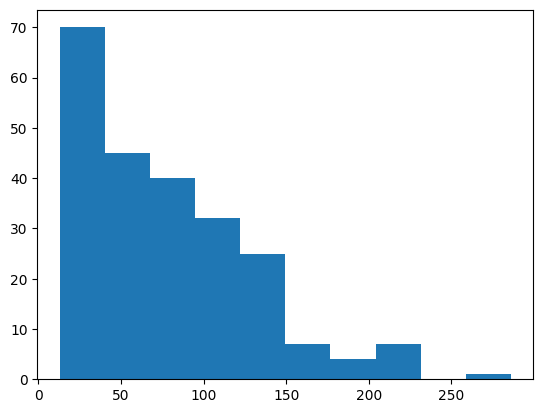

In [80]:
plt.hist(pw_vs_gene_counts.values())

In [81]:
# Check for duplicate rows
# np.all checks if all elements in an axis are True when comparing rows, np.any to see if any such rows exist
duplicates = np.any(np.all(pathway_sparse_mat.toarray()[indexes_to_include, None] == pathway_sparse_mat.toarray()[indexes_to_include], axis=2).sum(axis=0) > 1)

print("Are there any duplicate rows?:", duplicates)

Are there any duplicate rows?: False


In [82]:
final_pw_mask = pathway_sparse_mat.toarray()[indexes_to_include]

In [83]:
# sum(sum(pathway_mat_df[gene_names_to_retain].values == final_pw_mask))

In [84]:
final_pw_mask.shape

(231, 20193)

In [103]:
count = 0
cols_to_remove = []
cols_to_retain = []

for col_idx in range(final_pw_mask.shape[1]):
    if sum(final_pw_mask[:, col_idx])==0:
        count += 1
        cols_to_remove.append(col_idx)
    else:
        cols_to_retain.append(col_idx)

In [104]:
count

0

In [105]:
len(cols_to_retain)

6353

In [106]:
1989 + 1228

3217

In [107]:
final_pw_mask = final_pw_mask[:, cols_to_retain]

In [108]:
final_pw_mask

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [109]:
final_pw_mask.shape

(231, 6353)

In [92]:
np.save("final_pw_mask.npy", final_pw_mask)

In [93]:
np.load("final_pw_mask.npy").shape

(231, 6353)

In [94]:
import pickle

final_gene_columns = []

for gene_idx, gene_name in enumerate(common_genes):
    if gene_idx in cols_to_retain:
        final_gene_columns.append(gene_name)

In [95]:
len(final_gene_columns)

6353

In [96]:
with open(f"final_gene_columns.pickle", "wb") as file:
    pickle.dump(final_gene_columns, file)

In [97]:
merged_df.shape

(1078, 20201)

In [98]:
merged_df.head()

,SAMPLE_ID,133K02,5T4,A-C1,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,...,ZYG11A,ZYG11B,ZYX,ZZZ3,PATIENT_ID,CANCER_TYPE,SAMPLE_TYPE_ID,VIAL_NUMBER,OS_MONTHS,OS_STATUS
0,TCGA-3C-AALI-01,-1.1634,-1.1767,0.7383,0.6462,1.5168,-1.1186,-0.5741,0.3347,-0.4075,...,0.9389,-0.8990,0.9335,-1.8110,TCGA-3C-AALI,Breast Cancer,1,A,131.57,0
1,TCGA-3C-AALJ-01,-1.0405,-0.0972,-0.2167,1.3532,0.7521,0.4587,-0.3511,-0.6383,-1.1419,...,1.4057,-1.2453,0.9163,-1.2802,TCGA-3C-AALJ,Breast Cancer,1,A,48.42,0
2,TCGA-3C-AALK-01,-0.5932,1.7668,-0.2767,0.3809,0.0495,-1.1186,-0.0415,-0.5797,-0.7144,...,0.8269,-0.8818,1.0020,-0.5286,TCGA-3C-AALK,Breast Cancer,1,A,47.57,0
3,TCGA-4H-AAAK-01,-0.1301,0.9166,0.1489,0.7984,0.8357,-0.2521,-0.2346,0.4275,-0.4927,...,-1.4182,-0.2086,0.2990,0.0127,TCGA-4H-AAAK,Breast Cancer,1,A,11.43,0
4,TCGA-5L-AAT0-01,0.4422,0.7525,-0.8974,0.4597,0.3340,-1.1186,0.1282,0.5037,-0.8020,...,-1.3154,-0.7966,0.3444,0.4510,TCGA-5L-AAT0,Breast Cancer,1,A,48.52,0


In [ ]:
# merged_df = pd.concat([merged_df["SAMPLE_ID"], merged_df[final_gene_columns], merged_df["Label"]], axis=1)

In [ ]:
# merged_df.to_csv(f"mRNA_data_prepared.csv", index=False)

In [ ]:
# final_pw_names = []

# for pw_idx, pw_name in enumerate(list(pathway_mat_df.index)):
#     if pw_idx in indexes_to_include:
#         final_pw_names.append(pw_name)

In [ ]:
# final_pw_names

In [ ]:
# with open(f"final_pw_names.pickle", "wb") as file:
#     pickle.dump(final_pw_names, file)